### Mini Project Objective
The goal of this project is to build a machine learning model that can predict whether an employee earns more than **$100,000/year** based on their background.

The `Decision Tree Classifier` algorithm is used to analyse a dataset containing three key features:
* **Company** (Google, Facebook, ABC Pharma)
* **Job Role** (Sales Executive, Business Manager, Computer Programmer)
* **Degree** (Bachelors, Masters)

This notebook covers the full workflow: encoding categorical data, splitting the dataset, training the model, and evaluating its accuracy.

#### Limitation
Though the model achieved high accuracy (80%), it's important to note that it was trained on a very small dataset with limited features. 

### Importing Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import tree

### Load the dataset

In [3]:
df = pd.read_csv("salaries.csv")
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


### Partition dataset into independent & dependent variables

In [4]:
inputs = df.drop('salary_more_then_100k', axis='columns')
target = df['salary_more_then_100k']

In [5]:
print(target)

0     0
1     0
2     1
3     1
4     0
5     1
6     0
7     0
8     0
9     1
10    1
11    1
12    1
13    1
14    1
15    1
Name: salary_more_then_100k, dtype: int64


### Initialise Label Encoder

In [6]:
le = LabelEncoder()

### Encoding Categorical Variables/Features
Machine Learning models require **numerical input** to perform calculations. Since our dataset contains categorical text data ('company', 'job', 'degree'), we must convert these strings into numbers. Here, we use `fit_transform` to map each unique category to a specific number (e.g., 'Bachelors' - 0, 'Masters'- 1). 

In [7]:
inputs['company_n'] = le.fit_transform(inputs['company'])
inputs['job_n'] = le.fit_transform(inputs['job'])
inputs['degree_n'] = le.fit_transform(inputs['degree'])
inputs.head()

,company,job,degree,company_n,job_n,degree_n
0,google,sales executive,bachelors,2,2,0
1,google,sales executive,masters,2,2,1
2,google,business manager,bachelors,2,0,0
3,google,business manager,masters,2,0,1
4,google,computer programmer,bachelors,2,1,0


### Drop Categorical Columns
Since we have successfully encoded the variables into numbers (company_n, job_n, degree_n), we drop the original text columns to avoid redundancy and keep the dataset clean for training.

In [8]:
inputs_n = inputs.drop(['company', 'job', 'degree'], axis='columns')
inputs_n

,company_n,job_n,degree_n
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0
5,2,1,1
6,0,2,1
7,0,1,0
8,0,0,0
9,0,0,1


In [9]:
inputs_n.shape

(16, 3)

### Split data into training and test/validation sets

In [10]:
X_train, X_test, y_train, y_test = train_test_split(inputs_n, target, test_size=0.3, random_state=42)

In [11]:
# Gini is the default criterion, but trying out entropy here.
model = tree.DecisionTreeClassifier(criterion='entropy')

In [12]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [13]:
print(model.predict(X_test))
print()
print(y_test)

[0 0 0 1 1]

0     0
1     0
5     1
14    1
13    1
Name: salary_more_then_100k, dtype: int64


### Check Model Accuracy

In [14]:
model.score(X_test, y_test)

0.8

### Visualising The Tree

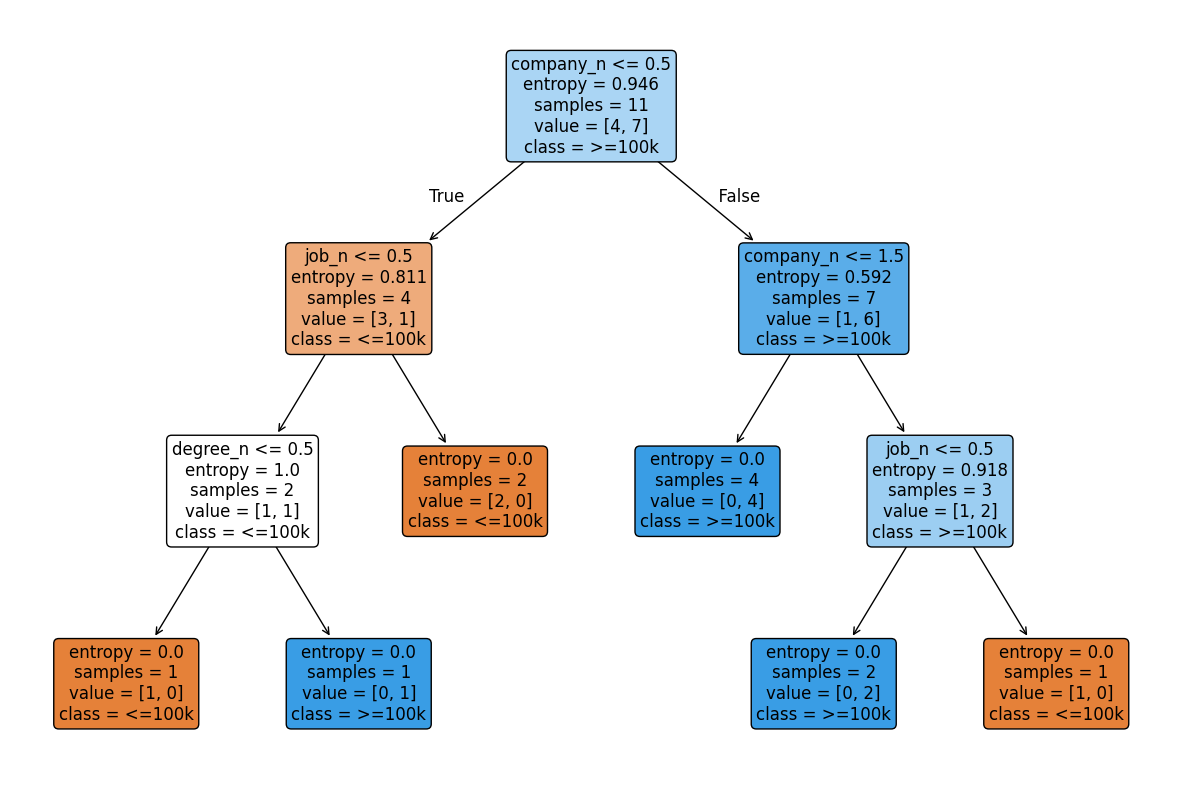

In [15]:
plt.figure(figsize=(15, 10))
tree.plot_tree(model, feature_names=['company_n', 'job_n', 'degree_n'], class_names=['<=100k', '>=100k'], filled=True, rounded=True, fontsize=12);